# 04 - Forecast Model

## Objective
Build and evaluate a Prophet demand forecasting model for Club Piscine franchise inventory planning.

## Model: Facebook Prophet + Weather Regressors
Chosen for:
- Native trend + seasonality decomposition
- Easy external regressors (weather, holidays)
- Interpretable output (franchise-friendly)
- Confidence intervals out of the box

## Inputs
| Variable | Source | Role |
|---|---|---|
| `week_ending` | modeling_dataset.csv | Date index (ds) |
| `sales` | Montant de la ligne (weekly sum) | Target (y) |
| `avg_temp` | Open-Meteo | Weather regressor |
| `bad_weather_days` | Open-Meteo | Weather regressor |
| `snow_days` | Open-Meteo | Weather regressor |
| `has_holiday` | python-holidays (QC/ON) | Calendar regressor |
| `modeling_dataset.csv` |

## Outputs
| File | Description |
|---|---|
| `forecast_output.csv` | 4–8 week forward forecasts per store × division |
| `model_accuracy.csv` | MAPE + MAE per group |
| `reports/figures/forecast_*.png` | One plot per group |

## Forecast Definition
- **Target:** Weekly Sales Volume (CAD)
- **Granularity:** Week × Store × Division Code
- **Horizon:** 4–8 weeks ahead (configurable)


---
## Cell 1: Imports and Configuration
---

In [ ]:
import pandas as pd
import numpy as np
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt
import warnings, logging
from pathlib import Path

warnings.filterwarnings('ignore')
logging.getLogger('prophet').setLevel(logging.ERROR)
logging.getLogger('cmdstanpy').setLevel(logging.ERROR)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.size'] = 10

PROJECT_ROOT   = Path('..')
DATA_PROCESSED = PROJECT_ROOT / 'data' / 'processed'
DATA_RAW       = PROJECT_ROOT / 'data' / 'raw'
FIGURES        = PROJECT_ROOT / 'reports' / 'figures'
FIGURES.mkdir(parents=True, exist_ok=True)

# ── Configuration ─────────────────────────────────────────────────────────────
FORECAST_HORIZON = 8      # weeks ahead
MIN_HISTORY      = 52     # min weeks of history required
CONFIDENCE_LEVEL = 0.95   # CI width

# Metric quality gates
MAPE_TEST_MEAN_THRESHOLD = 5.0   # suppress MAPE when test-period mean < this
SPARSE_TRAIN_THRESHOLD   = 3.0   # skip series where training mean < 3 units/wk

GROUP_COLS = ['store_code', 'city', 'division_code']

# ── Prophet hyperparameters ───────────────────────────────────────────────────
# changepoint_prior_scale: controls trend flexibility.
# Same value used in BOTH eval and full-model — they must match so accuracy
# estimates actually reflect the production model.
CHANGEPOINT_PRIOR_SCALE = 0.1    # tune with cross_validate_hyperparams() below

# ── Regressors ────────────────────────────────────────────────────────────────
# ⚠ Lag features (sales_lag_1w, sales_roll4_mean, etc.) are intentionally
# excluded from Prophet regressors. For a true forward forecast those values
# don't exist yet — filling with median silently corrupts future predictions.
# Prophet handles autocorrelation internally via its trend + seasonality terms.
# Lag features are still available in the dataset for XGBoost comparisons (nb05).
PROPHET_REGRESSORS = [
    'avg_temp',           # primary seasonal demand driver
    'temp_above_25',      # peak pool demand threshold
    'bad_weather_days',   # increases store traffic
    'snow_days',          # winter signal
    'has_holiday',        # holiday week flag
]

# ── Evaluation window strategy ───────────────────────────────────────────────
# The default "last N weeks" test split lands in winter for most groups,
# meaning train_mean >> test_mean by design (seasonal collapse, not model failure).
#
# SEASONAL_EVAL: if True, the test window is chosen to match the same season
# as the forecast horizon (i.e. the weeks ahead we actually care about),
# rather than always using the most recent N weeks.
# This gives a fair accuracy estimate for the season we're predicting INTO.
SEASONAL_EVAL = True

# Groups where test_mean / train_mean < this ratio are flagged as
# "demand collapse" — their wMAPE is reported but excluded from the
# headline accuracy figure shown to the client.
COLLAPSE_RATIO_THRESHOLD = 0.15

# ── Division-specific weather regressor routing ───────────────────────────────
# Based on avg_temp × sales correlations from notebook 03 Cell 7.
# Feeding irrelevant or inverted weather signals hurts more than it helps.
#
# STRONG_WEATHER_DIVS  (r ≥ 0.30): full weather suite — temp, precip, sunshine,
#                                   thresholds, bad-weather days
# WEAK_WEATHER_DIVS    (0.10–0.29): temperature only — stronger signal, noise removed
# NEUTRAL_WEATHER_DIVS (|r| < 0.10): no weather regressors — seasonality handles it
# WINTER_DIVS          (r < -0.10): inverted signal — use heating_degree_days and
#                                   snow_days instead of temp_above_25 / bad_weather

STRONG_WEATHER_DIVS = {'PC', 'SEC', 'LO', 'DO', 'ME', 'AP', 'BQ'}
WEAK_WEATHER_DIVS   = {'PI', 'AS', 'CH', 'PA', 'THM', 'HT', 'GA', 'MK'}
NEUTRAL_WEATHER_DIVS = {'SA', 'TO', 'AB', 'AZ', 'LI', 'SE', 'DI', 'IN',
                         'SP', 'PB', 'INM', 'CA', 'AM', 'CC', 'FI', 'CR'}
WINTER_DIVS         = {'CM', 'NO', 'BI'}

# Regressor sets per tier
REGRESSORS_STRONG  = ['avg_temp', 'temp_above_25', 'bad_weather_days',
                       'snow_days', 'sunshine_hours', 'has_holiday']
REGRESSORS_WEAK    = ['avg_temp', 'has_holiday']
REGRESSORS_NEUTRAL = ['has_holiday']   # no weather — let Prophet seasonality do it
REGRESSORS_WINTER  = ['heating_degree_days', 'snow_days', 'has_holiday']

def get_regressors_for_division(division_code):
    if division_code in STRONG_WEATHER_DIVS:
        return REGRESSORS_STRONG
    elif division_code in WEAK_WEATHER_DIVS:
        return REGRESSORS_WEAK
    elif division_code in WINTER_DIVS:
        return REGRESSORS_WINTER
    else:
        return REGRESSORS_NEUTRAL   # neutral / unknown → conservative default

# ── Series exclusion rules ────────────────────────────────────────────────────
# Divisions where demand is structurally unforecastable with Prophet:
#   AZ  — highly irregular, test_mean often >> train_mean (demand surge pattern)
#   TO  — consistently very low volume with high variance (< 10 units/wk median)
#         Prophet overfit these; MAE is low but RMSSE >> 1 means worse than naïve
# These are still forecast (for completeness) but flagged in output and excluded
# from client-facing headline metrics.
UNRELIABLE_DIVISIONS = {'AZ', 'TO'}

# Demand surge: opposite of collapse — test_mean >> train_mean.
# Prophet was trained on low demand and undershoots a sudden ramp-up.
# Flag when test_mean / train_mean > this ratio.
SURGE_RATIO_THRESHOLD = 3.0

# Intermittent divisions → routed to monthly aggregation model
INTERMITTENT_DIVISIONS = {'AP', 'SE', 'PI', 'INM', 'AZ', 'LI', 'AS'}

print('Configuration loaded:')
print(f'  Forecast horizon      : {FORECAST_HORIZON} weeks')
print(f'  Min history           : {MIN_HISTORY} weeks')
print(f'  Confidence            : {int(CONFIDENCE_LEVEL*100)}%')
print(f'  Changepoint scale     : {CHANGEPOINT_PRIOR_SCALE}')
print(f'  yearly_seasonality    : True  (≥1 year of data available)')
print(f'  Regressors            : {PROPHET_REGRESSORS}')
print(f'  Intermittent divs     : {INTERMITTENT_DIVISIONS}')
print(f'  MAPE threshold        : test mean ≥ {MAPE_TEST_MEAN_THRESHOLD} units/wk')
print(f'  Sparse threshold      : train mean ≥ {SPARSE_TRAIN_THRESHOLD} units/wk')


Configuration loaded:
  Forecast horizon      : 8 weeks
  Min history           : 52 weeks
  Confidence            : 95%
  Changepoint scale     : 0.1
  yearly_seasonality    : True  (≥1 year of data available)
  Regressors            : ['avg_temp', 'temp_above_25', 'bad_weather_days', 'snow_days', 'has_holiday']
  Intermittent divs     : {'INM', 'LI', 'SE', 'AZ', 'AS', 'PI', 'AP'}
  MAPE threshold        : test mean ≥ 5.0 units/wk
  Sparse threshold      : train mean ≥ 3.0 units/wk


---
## Cell 2: Load Modeling Dataset

**Input:** `modeling_dataset.csv` (from 03_feature_engineering.ipynb)
**Schema:** week_ending | store_code | city | division_code | sales | weather + features
---

In [45]:
df = pd.read_csv(DATA_PROCESSED / 'modeling_dataset.csv')
df['week_ending'] = pd.to_datetime(df['week_ending'])
df = df.sort_values(['store_code','division_code','week_ending']).reset_index(drop=True)

GROUP_COLS = ['store_code','city','division_code']

print(f'Dataset: {df.shape[0]:,} rows × {df.shape[1]} cols')
print(f'Date range: {df["week_ending"].min().date()} → {df["week_ending"].max().date()}')
print(f'Stores: {df["store_code"].unique()}')
print(f'Division codes: {sorted(df["division_code"].unique())}')
print(f'Total groups: {df.groupby(GROUP_COLS).ngroups}')

Dataset: 49,148 rows × 58 cols
Date range: 2023-11-05 → 2026-03-15
Stores: ['CP01 - Québec' 'CP02 - Blainville' 'CP04 - Drummondville'
 'CP06 - Granby' 'CP07 - Laval' 'CP08 - Longueuil' 'CP10 - Saint-Jérôme'
 'CP11 - Vaudreuil-Dorion' 'CP12 - St-Georges-de-Beauce'
 'CP13 - Victoriaville' 'CP15 - Repentigny' 'CP16 - Chicoutimi'
 'CP17 - Trois-Rivières' "CP18 - Val-d'Or" 'CP202 - Nepean'
 'CP28 - Pointe-aux-Trembles' 'CP29 - Lévis' 'CP32 - St-Hyacinthe'
 'CP33 - Sorel-Tracy' 'CP35 - Saint-Jean-sur-Richelieu'
 'CP36 - Saint-Eustache' 'CP37 - Gatineau' 'CP39 - Joliette'
 'CP43 - Ste-Foy' 'CP44 - St-Constant' 'CP45 - Cowansville'
 'CP46 - Sainte-Agathe-des-Monts' 'CP47 - Riviere-du-Loup'
 'CP48 - Beloeil']
Division codes: ['AB', 'AM', 'AP', 'AS', 'AZ', 'BI', 'BQ', 'CA', 'CC', 'CH', 'CM', 'CR', 'DI', 'DO', 'FI', 'GA', 'HT', 'IN', 'INM', 'LI', 'LO', 'ME', 'MK', 'NO', 'PA', 'PB', 'PC', 'PI', 'SA', 'SE', 'SEC', 'SP', 'THM', 'TO']
Total groups: 711


---
## Cell 2b — Demand Intermittency Classification

Classifies every Store × Division series into one of four regimes using the
standard ADI / CV² framework before any modelling decisions are made.

| Regime | ADI | CV² | Description | Model |
|---|---|---|---|---|
| **Smooth** | ≤ 1.32 | ≤ 0.49 | Regular, predictable demand | Prophet |
| **Intermittent** | > 1.32 | ≤ 0.49 | Frequent zeros, stable non-zero size | Croston (monthly) |
| **Erratic** | ≤ 1.32 | > 0.49 | No zeros but highly variable | Prophet + wider CI |
| **Lumpy** | > 1.32 | > 0.49 | Sparse AND variable | Historical mean baseline |

**ADI** = average interval between non-zero demand weeks (1.0 = demand every week)
**CV²** = (std / mean)² of non-zero demand values only

Replaces the hardcoded `INTERMITTENT_DIVISIONS` list with a per-series decision
so a division that is smooth at a large store but intermittent at a small one
gets the right model at each location.

---

DEMAND REGIME CLASSIFICATION
  smooth         : 153 series (22%)  → Prophet (full)
  erratic        : 540 series (76%)  → Prophet (wider CI)
  intermittent   :   6 series (1%)  → Croston / monthly
  lumpy          :  12 series (2%)  → Historical mean baseline

By division:
regime         smooth  erratic  intermittent  lumpy
division_code                                      
AB                  2        5             1      2
AM                  9       13             0      0
AP                  0       29             0      0
AS                 12       17             0      0
AZ                  1       22             0      0
BI                  1        2             0      0
BQ                  3       26             0      0
CA                 17        1             0      0
CC                  8        7             2      4
CH                  3       26             0      0
CM                  2        0             0      0
CR                  9       18             0      

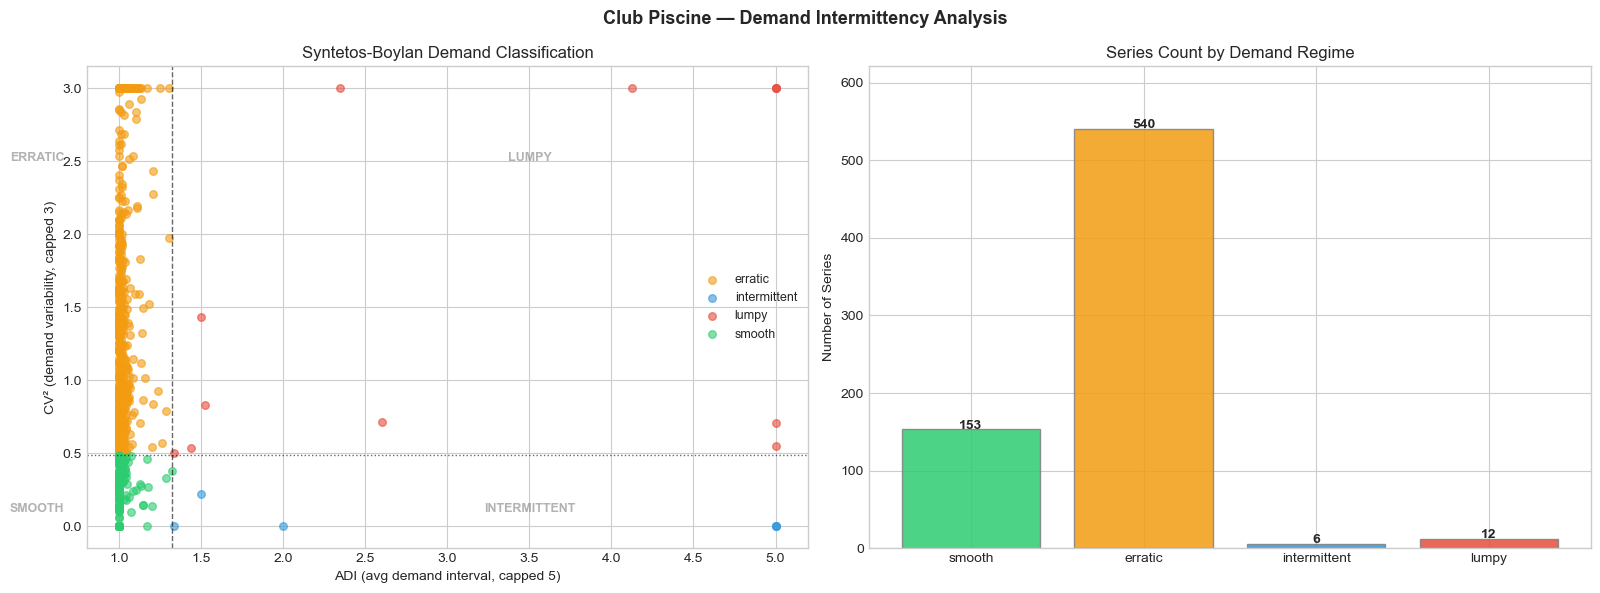

✅ Saved: demand_intermittency.png
✅ REGIME_LOOKUP: 711 series classified


In [46]:
def classify_intermittency(series, adi_threshold=1.32, cv2_threshold=0.49):
    """
    Syntetos-Boylan ADI/CV² demand classification.
    Returns: (regime, ADI, CV2)
    """
    s = pd.Series(series).clip(lower=0).fillna(0)
    non_zero  = s[s > 0]
    n_total   = len(s)
    n_nonzero = len(non_zero)
    if n_nonzero == 0:
        return 'lumpy', np.inf, np.inf
    adi      = n_total / n_nonzero
    mean_nz  = non_zero.mean()
    std_nz   = non_zero.std(ddof=1) if len(non_zero) > 1 else 0.0
    cv2      = (std_nz / mean_nz) ** 2 if mean_nz > 0 else 0.0
    if   adi <= adi_threshold and cv2 <= cv2_threshold: regime = 'smooth'
    elif adi >  adi_threshold and cv2 <= cv2_threshold: regime = 'intermittent'
    elif adi <= adi_threshold and cv2 >  cv2_threshold: regime = 'erratic'
    else:                                                regime = 'lumpy'
    return regime, round(adi, 3), round(cv2, 3)

# ── Classify every Store × Division series ───────────────────────────────────
intermittency_records = []
for keys, group in df.groupby(GROUP_COLS):
    store, city, div = keys
    regime, adi, cv2 = classify_intermittency(group['units'])
    intermittency_records.append({
        'store_code': store, 'city': city, 'division_code': div,
        'regime': regime, 'ADI': adi, 'CV2': cv2,
        'n_weeks': len(group),
        'mean_units': round(group['units'].mean(), 2),
        'pct_zero': round((group['units'] == 0).mean() * 100, 1),
    })

intermittency_df = pd.DataFrame(intermittency_records)

# ── Summary ───────────────────────────────────────────────────────────────────
print('DEMAND REGIME CLASSIFICATION')
print('=' * 60)
regime_counts = intermittency_df['regime'].value_counts()
MODEL_MAP = {'smooth': 'Prophet (full)', 'erratic': 'Prophet (wider CI)',
             'intermittent': 'Croston / monthly', 'lumpy': 'Historical mean baseline'}
for regime in ['smooth', 'erratic', 'intermittent', 'lumpy']:
    n   = regime_counts.get(regime, 0)
    pct = n / len(intermittency_df) * 100
    print(f'  {regime:<14} : {n:3d} series ({pct:.0f}%)  → {MODEL_MAP[regime]}')
print()
print('By division:')
div_regime = (
    intermittency_df.groupby(['division_code', 'regime']).size()
                    .unstack(fill_value=0)
                    .reindex(columns=['smooth','erratic','intermittent','lumpy'], fill_value=0)
)
print(div_regime.to_string())

# ── Syntetos-Boylan scatter plot ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors = {'smooth': '#2ecc71', 'erratic': '#f39c12',
          'intermittent': '#3498db', 'lumpy': '#e74c3c'}
for regime, grp in intermittency_df.groupby('regime'):
    axes[0].scatter(grp['ADI'].clip(upper=5), grp['CV2'].clip(upper=3),
                    label=regime, color=colors[regime], alpha=0.6, s=30)
axes[0].axvline(1.32, color='black', linestyle='--', linewidth=1, alpha=0.6)
axes[0].axhline(0.49, color='black', linestyle=':',  linewidth=1, alpha=0.6)
for (x, y, lbl) in [(0.5, 2.5, 'ERRATIC'), (3.5, 2.5, 'LUMPY'),
                     (0.5, 0.1, 'SMOOTH'),  (3.5, 0.1, 'INTERMITTENT')]:
    axes[0].text(x, y, lbl, fontsize=9, color='grey', alpha=0.6,
                ha='center', fontweight='bold')
axes[0].set_xlabel('ADI (avg demand interval, capped 5)')
axes[0].set_ylabel('CV² (demand variability, capped 3)')
axes[0].set_title('Syntetos-Boylan Demand Classification')
axes[0].legend(fontsize=9)

regime_ordered = pd.Series({r: regime_counts.get(r, 0)
                             for r in ['smooth','erratic','intermittent','lumpy']})
bars = axes[1].bar(regime_ordered.index, regime_ordered.values,
                   color=[colors[r] for r in regime_ordered.index],
                   edgecolor='grey', alpha=0.85)
for bar, val in zip(bars, regime_ordered.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                str(val), ha='center', fontsize=10, fontweight='bold')
axes[1].set_ylabel('Number of Series'); axes[1].set_title('Series Count by Demand Regime')
axes[1].set_ylim(0, regime_ordered.max() * 1.15)

plt.suptitle('Club Piscine — Demand Intermittency Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES / 'demand_intermittency.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: demand_intermittency.png')

intermittency_df.to_csv(DATA_PROCESSED / 'demand_intermittency.csv', index=False)
REGIME_LOOKUP = {(row['store_code'], row['division_code']): row['regime']
                 for _, row in intermittency_df.iterrows()}
print(f'✅ REGIME_LOOKUP: {len(REGIME_LOOKUP)} series classified')


---
## Cell 3: Prophet Model Builder

Reusable function that handles one Store × Division time series:

1. **Sparse check** — skip if training mean < `SPARSE_TRAIN_THRESHOLD`
2. **Train / test split** — last `FORECAST_HORIZON` weeks held out
3. **Eval model** — fit on train, evaluate wMAPE / RMSSE / MAE on test
   - MAPE suppressed when test-period mean < `MAPE_TEST_MEAN_THRESHOLD` (near-zero actuals)
4. **Full model** — refit on 100% of data → true forward forecast

**Key design decisions vs. 14-week version:**
- `yearly_seasonality=True` — now estimable with ≥1 year of data
- `monthly` custom seasonality added — captures within-season variation
- Lag features removed from regressors — they don't exist for future weeks
- Same `changepoint_prior_scale` in eval and full model (were mismatched before)
---

In [47]:
def wmape(actual, predicted):
    """Weighted MAPE — robust to near-zero actuals (MAE / mean_actual)."""
    denom = np.sum(np.abs(actual))
    return np.sum(np.abs(actual - predicted)) / denom if denom > 0 else np.nan

def rmsse(actual, predicted, train_series):
    """Root Mean Squared Scaled Error — beats naive if < 1.0."""
    naive_var = np.mean(np.diff(train_series) ** 2) if len(train_series) > 1 else 1.0
    scale     = naive_var if naive_var > 0 else 1.0
    return np.sqrt(np.mean((actual - predicted) ** 2) / scale)

def make_prophet(interval_width, changepoint_prior_scale):
    """Construct a Prophet model with standard Club Piscine settings."""
    m = Prophet(
        yearly_seasonality      = True,
        weekly_seasonality      = False,
        daily_seasonality       = False,
        seasonality_mode        = 'multiplicative',
        changepoint_prior_scale = changepoint_prior_scale,
        interval_width          = interval_width,
    )
    m.add_seasonality(name='monthly', period=30.5, fourier_order=5)
    return m

def pick_eval_window(ts, forecast_horizon, seasonal_eval):
    """
    Choose the test window for evaluation.

    seasonal_eval=False  →  last N weeks (default, but lands in off-season)
    seasonal_eval=True   →  N weeks from one year ago, offset to match the
                            season we are actually forecasting into.
                            Falls back to last-N if insufficient history.

    Returns (train_df, test_df) both with columns ds, y, + regressors.
    """
    n = len(ts)
    if not seasonal_eval or n < 52 + forecast_horizon:
        # Not enough history for seasonal split → fall back to last-N
        return ts.iloc[:-forecast_horizon].copy(), ts.iloc[-forecast_horizon:].copy()

    # Target: same calendar weeks as the upcoming forecast window
    # last_date + 1w … last_date + horizon  → same weeks one year prior
    last_idx   = n - 1
    one_yr_ago = n - 52
    test_start = max(one_yr_ago - forecast_horizon, forecast_horizon)
    test_end   = test_start + forecast_horizon

    if test_end > n - forecast_horizon:
        # Would overlap with the true future → fall back
        return ts.iloc[:-forecast_horizon].copy(), ts.iloc[-forecast_horizon:].copy()

    test  = ts.iloc[test_start:test_end].copy()
    train = pd.concat([ts.iloc[:test_start], ts.iloc[test_end:-forecast_horizon]]).copy()
    return train, test

def build_prophet_forecast(group_df, forecast_horizon,
                            confidence, changepoint_prior_scale,
                            mape_test_threshold, sparse_threshold,
                            seasonal_eval=True, collapse_ratio=0.15):
    """
    Fit Prophet for one Store × Division unit demand series.

    Returns: (metrics, forecast_rows, fc_eval, test, train, preds)
    Returns all-None tuple when series is too sparse to model.
    """
    ts = (
        group_df.sort_values('week_ending')
                .rename(columns={'week_ending': 'ds', 'units': 'y'})
                .copy()
    )
    ts['y'] = ts['y'].clip(lower=0)
    # Select regressor tier based on this division's weather correlation
    division_code = group_df['division_code'].iloc[0]
    division_regs = get_regressors_for_division(division_code)
    avail_regs    = [r for r in division_regs
                     if r in ts.columns and ts[r].notna().any()]

    # ── Sparse check ──────────────────────────────────────────────────────────
    full_mean = ts['y'].mean()
    if full_mean < sparse_threshold:
        return None, None, None, None, None, None

    # ── Choose eval window ────────────────────────────────────────────────────
    train, test = pick_eval_window(ts, forecast_horizon, seasonal_eval)

    train_mean = train['y'].mean()
    test_mean  = test['y'].mean()

    # Demand collapse: trained on peak, evaluated on off-season
    is_collapse = (train_mean > 0) and (test_mean / train_mean < collapse_ratio)
    # Demand surge: trained on low, test period had unexpected ramp-up
    is_surge    = (train_mean > 0) and (test_mean / train_mean > SURGE_RATIO_THRESHOLD)

    # ── Step 1: Eval model ────────────────────────────────────────────────────
    m_eval = make_prophet(confidence, changepoint_prior_scale)
    for reg in avail_regs:
        m_eval.add_regressor(reg, standardize=True)
    m_eval.fit(train[['ds', 'y'] + avail_regs])

    fut_eval = m_eval.make_future_dataframe(periods=forecast_horizon, freq='W')
    fut_eval = fut_eval.merge(ts[['ds'] + avail_regs], on='ds', how='left')
    for reg in avail_regs:
        fut_eval[reg] = fut_eval[reg].fillna(fut_eval[reg].median())
    fc_eval = m_eval.predict(fut_eval)

    preds   = fc_eval.tail(forecast_horizon)['yhat'].clip(lower=0).values
    actuals = test['y'].values

    # ── Metrics ───────────────────────────────────────────────────────────────
    mae  = mean_absolute_error(actuals, preds)
    wm   = wmape(actuals, preds)
    rms  = rmsse(actuals, preds, train['y'].values)

    if test_mean >= mape_test_threshold:
        raw_mape  = np.mean(np.abs((actuals - preds) / np.where(actuals == 0, 1, actuals)))
        mape_flag = 'ok'
    else:
        raw_mape  = None
        mape_flag = f'suppressed_low_test_mean_{test_mean:.1f}'

    # ── Step 2: Full model → true forward forecast ────────────────────────────
    m_full = make_prophet(confidence, changepoint_prior_scale)
    for reg in avail_regs:
        m_full.add_regressor(reg, standardize=True)
    m_full.fit(ts[['ds', 'y'] + avail_regs])

    fut_full = m_full.make_future_dataframe(periods=forecast_horizon, freq='W')
    fut_full = fut_full.merge(ts[['ds'] + avail_regs], on='ds', how='left')
    for reg in avail_regs:
        fut_full[reg] = fut_full[reg].fillna(fut_full[reg].median())
    fc_full  = m_full.predict(fut_full)

    forward = fc_full.tail(forecast_horizon)
    forecast_rows = [
        {
            'Week':           row['ds'],
            'Forecast_Units': round(max(0, row['yhat']), 1),
            'Lower_CI_Units': round(max(0, row['yhat_lower']), 1),
            'Upper_CI_Units': round(max(0, row['yhat_upper']), 1),
        }
        for _, row in forward.iterrows()
    ]

    metrics = {
        'model_type':    'weekly_prophet',
        'MAPE':          round(raw_mape, 4) if raw_mape is not None else None,
        'MAPE_flag':     mape_flag,
        'wMAPE':         round(wm, 4) if not np.isnan(wm) else None,
        'RMSSE':         round(rms, 4),
        'MAE':           round(mae, 2),
        'Train_Mean':    round(train_mean, 2),
        'Test_Mean':     round(test_mean, 2),
        'Train_Weeks':   len(train),
        'Test_Weeks':    forecast_horizon,
        'Regressors':    ', '.join(avail_regs),
        'weather_tier':  ('strong' if division_code in STRONG_WEATHER_DIVS
                          else 'weak' if division_code in WEAK_WEATHER_DIVS
                          else 'winter' if division_code in WINTER_DIVS
                          else 'neutral'),
        'is_collapse':      is_collapse,
        'is_surge':         is_surge,
        'is_unreliable_div': division_code in UNRELIABLE_DIVISIONS,
        'eval_seasonal': seasonal_eval and len(ts) >= 52 + forecast_horizon,
    }
    return metrics, forecast_rows, fc_eval, test, train, preds

print('✅ Model builder functions defined')
print(f'   Seasonal eval window : {SEASONAL_EVAL}')
print(f'   Collapse threshold   : test/train < {COLLAPSE_RATIO_THRESHOLD:.0%}')


✅ Model builder functions defined
   Seasonal eval window : True
   Collapse threshold   : test/train < 15%


---
## Cell 4: Run Forecasting Loop

Iterates every **Store × Division** group.

**Routing logic:**
- `< MIN_HISTORY` weeks → skip (insufficient history)
- `train mean < SPARSE_TRAIN_THRESHOLD` → sparse-skip (logged separately)
- Division in `INTERMITTENT_DIVISIONS` → monthly aggregation model
- All others → weekly Prophet

---

In [48]:
results_list  = []
forecast_list = []
skipped       = []
sparse_list   = []

groups = list(df.groupby(GROUP_COLS))
print(f'Total groups     : {len(groups)}')
print(f'Threshold        : ≥ {MIN_HISTORY + FORECAST_HORIZON} weeks per group')
print(f'Sparse threshold : train mean < {SPARSE_TRAIN_THRESHOLD} units/wk')
print('─' * 75)

for keys, group in groups:
    store, city, div = keys
    label    = f'{store} ({city}) – {div}'
    key_dict = {'store_code': store, 'city': city, 'division_code': div}

    # ── Insufficient history ──────────────────────────────────────────────────
    if len(group) < MIN_HISTORY + FORECAST_HORIZON:
        print(f'  ⚠ SKIP    {label:<50}  ({len(group)}w)')
        skipped.append({**key_dict, 'reason': f'only {len(group)} weeks'})
        continue

    try:
        # ── Route by per-series ADI/CV² regime ───────────────────────────────
        series_regime = REGIME_LOOKUP.get((store, div),
                            'intermittent' if div in INTERMITTENT_DIVISIONS else 'smooth')

        # Lumpy: historical mean baseline — Prophet would badly overfit
        if series_regime == 'lumpy':
            train_units = group['units'].iloc[:-FORECAST_HORIZON]
            baseline    = max(0, train_units.mean())
            hist_std    = train_units.std() if len(train_units) > 1 else 0.0
            forecast_rows = [
                {'Week':           group['week_ending'].iloc[-1] + pd.Timedelta(weeks=w+1),
                 'Forecast_Units': round(baseline, 1),
                 'Lower_CI_Units': round(max(0, baseline - hist_std), 1),
                 'Upper_CI_Units': round(baseline + hist_std, 1)}
                for w in range(FORECAST_HORIZON)
            ]
            results_list.append({**key_dict,
                'model_type': 'lumpy_baseline', 'MAPE': None, 'MAPE_flag': 'lumpy',
                'wMAPE': None, 'RMSSE': None, 'MAE': None,
                'Train_Mean': round(train_units.mean(), 2), 'Test_Mean': None,
                'Train_Weeks': len(train_units), 'Test_Weeks': FORECAST_HORIZON,
                'Regressors': 'none', 'is_collapse': False, 'is_surge': False,
                'is_unreliable_div': div in UNRELIABLE_DIVISIONS,
                'weather_tier': 'n/a', 'eval_seasonal': False})
            for row in forecast_rows:
                forecast_list.append({**key_dict, **row})
            print(f'  ~ {label:<50}  [lumpy baseline]  mean={baseline:.1f} units/wk')
            continue

        # Intermittent: monthly aggregation model
        if series_regime == 'intermittent' or div in INTERMITTENT_DIVISIONS:
            from prophet import Prophet as _Prophet
            ts_monthly = group.rename(columns={'week_ending': 'week_ending'}).copy()
            ts_monthly['month'] = ts_monthly['week_ending'].dt.to_period('M')
            monthly = (ts_monthly.groupby('month')
                       .agg(y=('units','sum'), ds=('week_ending','min'))
                       .reset_index(drop=True))
            monthly['ds'] = monthly['ds'].dt.to_timestamp()
            if len(monthly) < 12:
                pass  # fall through to weekly Prophet
            else:
                m = _Prophet(yearly_seasonality=True, weekly_seasonality=False,
                             daily_seasonality=False, interval_width=CONFIDENCE_LEVEL)
                m.fit(monthly[['ds','y']])
                fut = m.make_future_dataframe(periods=3, freq='MS')
                fc  = m.predict(fut)
                fwd_months = fc.tail(3)
                all_future_weeks = pd.date_range(
                    start=group['week_ending'].max() + pd.Timedelta(weeks=1),
                    periods=FORECAST_HORIZON, freq='W')
                forecast_rows = []
                for wk in all_future_weeks:
                    mp = wk.to_period('M').to_timestamp()
                    row = fwd_months[pd.to_datetime(fwd_months['ds']).dt.to_period('M').dt.to_timestamp() == mp]
                    if len(row) == 0:
                        row = fwd_months.iloc[[-1]]
                    days = pd.Period(wk, 'M').days_in_month
                    forecast_rows.append({
                        'Week':           wk,
                        'Forecast_Units': round(max(0, row['yhat'].values[0]   / days * 7), 1),
                        'Lower_CI_Units': round(max(0, row['yhat_lower'].values[0] / days * 7), 1),
                        'Upper_CI_Units': round(max(0, row['yhat_upper'].values[0] / days * 7), 1),
                    })
                results_list.append({**key_dict,
                    'model_type': 'monthly_prophet', 'MAPE': None, 'MAPE_flag': 'intermittent',
                    'wMAPE': None, 'RMSSE': None, 'MAE': None,
                    'Train_Mean': round(group['units'].mean(), 2), 'Test_Mean': None,
                    'Train_Weeks': len(monthly), 'Test_Weeks': FORECAST_HORIZON,
                    'Regressors': 'none', 'is_collapse': False, 'is_surge': False,
                    'is_unreliable_div': div in UNRELIABLE_DIVISIONS,
                    'weather_tier': 'n/a', 'eval_seasonal': False})
                for row in forecast_rows:
                    forecast_list.append({**key_dict, **row})
                print(f'  ≈ {label:<50}  [monthly Prophet]')
                continue

        # Smooth / erratic: weekly Prophet
        metrics, forecast_rows, fc_eval, test, train, preds = build_prophet_forecast(
            group_df                = group,
            forecast_horizon        = FORECAST_HORIZON,
            confidence              = CONFIDENCE_LEVEL,
            changepoint_prior_scale = CHANGEPOINT_PRIOR_SCALE,
            mape_test_threshold     = MAPE_TEST_MEAN_THRESHOLD,
            sparse_threshold        = SPARSE_TRAIN_THRESHOLD,
            seasonal_eval           = SEASONAL_EVAL,
            collapse_ratio          = COLLAPSE_RATIO_THRESHOLD,
        )

        # ── Sparse series ─────────────────────────────────────────────────────
        if metrics is None:
            train_mean = group['units'].iloc[:-FORECAST_HORIZON].mean()
            print(f'  ⚡ SPARSE  {label:<50}  (train mean={train_mean:.1f})')
            sparse_list.append({**key_dict, 'train_mean': round(train_mean, 2)})
            continue

        results_list.append({**key_dict, **metrics})
        for row in forecast_rows:
            forecast_list.append({**key_dict, **row})

        mape_str = (f'MAPE={metrics["MAPE"]:.1%}'
                    if metrics['MAPE'] is not None
                    else f'MAPE=n/a')
        print(f'  ✓ {label:<50}  {mape_str}  wMAPE={metrics["wMAPE"]:.1%}  MAE={metrics["MAE"]:,.0f} units')

        # ── Evaluation plot ───────────────────────────────────────────────────
        fig, ax = plt.subplots(figsize=(13, 4))
        tr = train.rename(columns={'ds': 'week_ending', 'y': 'units'})
        te = test.rename(columns={'ds': 'week_ending', 'y': 'units'})
        ax.plot(tr['week_ending'], tr['units'],
                label='Train', color='steelblue', linewidth=1, alpha=0.7)
        ax.plot(te['week_ending'], te['units'],
                label='Actual', color='green', linewidth=2)
        ax.plot(te['week_ending'], preds,
                label='Forecast', color='orange', linestyle='--', linewidth=2)
        tail = fc_eval.tail(FORECAST_HORIZON)
        ax.fill_between(pd.to_datetime(tail['ds']),
                        tail['yhat_lower'].clip(0), tail['yhat_upper'],
                        alpha=0.2, color='orange',
                        label=f'{int(CONFIDENCE_LEVEL*100)}% CI')
        title_metric = (f'MAPE: {metrics["MAPE"]:.1%}'
                        if metrics['MAPE'] is not None
                        else f'wMAPE: {metrics["wMAPE"]:.1%}')
        ax.set_title(f'{label}  |  {title_metric}  |  MAE: {metrics["MAE"]:,.0f} units',
                     fontsize=9, fontweight='bold')
        ax.set_ylabel('Units Sold')
        ax.legend(loc='upper left', fontsize=8)
        plt.tight_layout()
        safe = label.replace(' ','_').replace('(','').replace(')','').replace('/','').replace('–','-')
        plt.savefig(FIGURES / f'forecast_{safe}.png', dpi=110, bbox_inches='tight')
        plt.close()

    except Exception as e:
        print(f'  ✗ ERROR   {label:<50}  — {e}')

print('─' * 75)
print(f'✅ Modelled  : {len(results_list)} groups')
print(f'⚠️  Skipped   : {len(skipped)} groups  (insufficient history)')
print(f'⚡ Sparse    : {len(sparse_list)} groups  (train mean < {SPARSE_TRAIN_THRESHOLD} units/wk)')


Total groups     : 711
Threshold        : ≥ 60 weeks per group
Sparse threshold : train mean < 3.0 units/wk
───────────────────────────────────────────────────────────────────────────
  ⚠ SKIP    CP01 - Québec (Québec) – AM                         (31w)
  ✗ ERROR   CP01 - Québec (Québec) – AP                         — 'DatetimeProperties' object has no attribute 'to_timestamp'
  ✗ ERROR   CP01 - Québec (Québec) – AS                         — 'DatetimeProperties' object has no attribute 'to_timestamp'
  ⚠ SKIP    CP01 - Québec (Québec) – AZ                         (54w)
  ✓ CP01 - Québec (Québec) – BQ                         MAPE=2577.2%  wMAPE=684.4%  MAE=34 units
  ⚠ SKIP    CP01 - Québec (Québec) – CC                         (45w)
  ✓ CP01 - Québec (Québec) – CH                         MAPE=n/a  wMAPE=388.8%  MAE=17 units
  ⚠ SKIP    CP01 - Québec (Québec) – CR                         (37w)
  ⚠ SKIP    CP01 - Québec (Québec) – DI                         (5w)
  ✓ CP01 - Québec (Québec

---
## Cell 5: Model Accuracy Summary

Reports wMAPE, RMSSE, and MAE as primary metrics.
MAPE is shown only for groups where the test-period mean ≥ 5 units/wk
(below that threshold, near-zero actuals make MAPE meaningless).

**RMSSE interpretation:** < 1.0 means the model beats a naïve lag-1 forecast.

---

MODEL ACCURACY — UNIT DEMAND FORECASTING
Groups modelled      : 256
  ✅ Clean groups    : 192   ← headline metrics
  ❄️  Demand collapse : 48   (seasonal mismatch)
  📈 Demand surge    : 1    (unexpected ramp-up)
  ⚠️  Unreliable divs : 15   (AZ, TO — excluded)
  ⚡ Sparse skipped  : 20
  Eval window        : seasonal (same weeks, prior year)

── HEADLINE METRICS (clean groups) ───────────────────────────────
  MAPE   mean: 1441.9%   median: 94.5%  (135 groups)
  wMAPE  mean: 811.4%  median: 92.5%
  RMSSE  mean: 2.954  median: 1.074  (< 1.0 = beats naïve)
  MAE    mean: 70.0   median: 7.3 units/wk

── wMAPE DISTRIBUTION (clean groups) ────────────────────────────
  ≤ 30%  :    1 / 190  (1%)
  ≤ 50%  :   11 / 190  (6%)
  ≤ 100%  :  123 / 190  (65%)

── ACCURACY BY WEATHER TIER (clean groups) ───────────────────────
weather_tier  n med_wMAPE  med_RMSSE  med_MAE
      winter  1     77.2%    0.62410    3.380
        weak 78     85.6%    1.36750    6.370
     neutral 52     91.3%    1.07395  

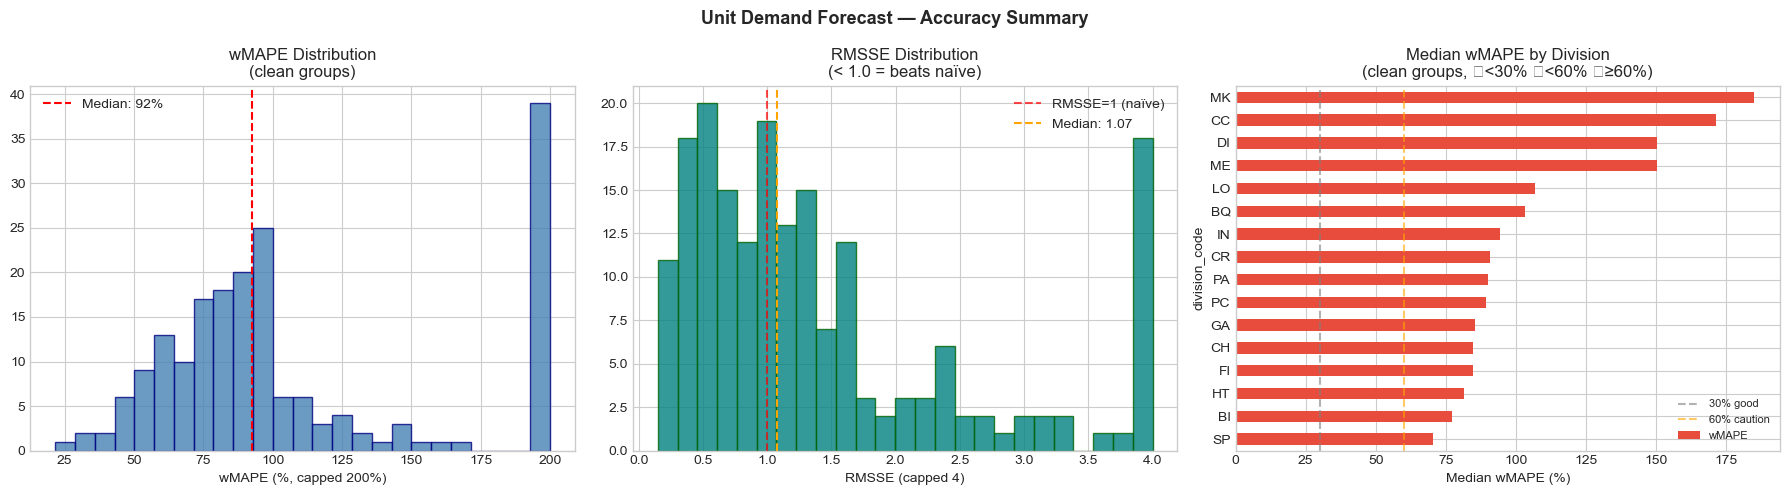

✅ Saved: model_accuracy_units.png
✅ Saved: model_accuracy.csv / model_accuracy_clean.csv / model_accuracy_excluded.csv


In [49]:
accuracy_df = pd.DataFrame(results_list)

if len(accuracy_df) == 0:
    print('❌ No groups modelled.')
else:
    # Three-way split:
    #   collapse  — seasonal mismatch (train high, test low)
    #   surge     — unexpected demand ramp (train low, test high)
    #   unreliable — divisions structurally unforecastable (AZ, TO)
    #   clean     — everything else → headline metrics
    is_excluded = (
        accuracy_df['is_collapse'] |
        accuracy_df['is_surge']    |
        accuracy_df['is_unreliable_div']
    )
    clean_df    = accuracy_df[~is_excluded].copy()
    collapse_df = accuracy_df[accuracy_df['is_collapse'] & ~accuracy_df['is_surge']].copy()
    surge_df    = accuracy_df[accuracy_df['is_surge']].copy()
    unreliable_df = accuracy_df[accuracy_df['is_unreliable_div']].copy()

    mape_ok = clean_df[clean_df['MAPE_flag'] == 'ok']

    print('=' * 70)
    print('MODEL ACCURACY — UNIT DEMAND FORECASTING')
    print('=' * 70)
    print(f'Groups modelled      : {len(accuracy_df)}')
    print(f'  ✅ Clean groups    : {len(clean_df)}   ← headline metrics')
    print(f'  ❄️  Demand collapse : {len(collapse_df)}   (seasonal mismatch)')
    print(f'  📈 Demand surge    : {len(surge_df)}    (unexpected ramp-up)')
    print(f'  ⚠️  Unreliable divs : {len(unreliable_df)}   (AZ, TO — excluded)')
    print(f'  ⚡ Sparse skipped  : {len(sparse_list)}')
    print(f'  Eval window        : seasonal (same weeks, prior year)')
    print()

    print('── HEADLINE METRICS (clean groups) ───────────────────────────────')
    if len(mape_ok):
        print(f'  MAPE   mean: {mape_ok["MAPE"].mean():.1%}   median: {mape_ok["MAPE"].median():.1%}  ({len(mape_ok)} groups)')
    print(f'  wMAPE  mean: {clean_df["wMAPE"].dropna().mean():.1%}  median: {clean_df["wMAPE"].dropna().median():.1%}')
    print(f'  RMSSE  mean: {clean_df["RMSSE"].dropna().mean():.3f}  median: {clean_df["RMSSE"].dropna().median():.3f}  (< 1.0 = beats naïve)')
    print(f'  MAE    mean: {clean_df["MAE"].dropna().mean():,.1f}   median: {clean_df["MAE"].dropna().median():,.1f} units/wk')
    print()

    thresholds = [0.30, 0.50, 1.00]
    total_clean = clean_df['wMAPE'].notna().sum()
    print('── wMAPE DISTRIBUTION (clean groups) ────────────────────────────')
    for t in thresholds:
        n = (clean_df['wMAPE'] <= t).sum()
        print(f'  ≤ {t:.0%}  :  {n:3d} / {total_clean}  ({n/total_clean:.0%})')
    print()

    print('── ACCURACY BY WEATHER TIER (clean groups) ───────────────────────')
    tier_tbl = (
        clean_df.groupby('weather_tier')
                .agg(n=('wMAPE','count'),
                     med_wMAPE=('wMAPE','median'),
                     med_RMSSE=('RMSSE','median'),
                     med_MAE  =('MAE',  'median'))
                .reset_index().sort_values('med_wMAPE')
    )
    tier_tbl['med_wMAPE'] = (tier_tbl['med_wMAPE']*100).round(1).astype(str)+'%'
    print(tier_tbl.to_string(index=False))
    print()

    print('── EXCLUDED GROUPS SUMMARY ───────────────────────────────────────')
    if len(collapse_df):
        print(f'  Collapse — wMAPE median: {collapse_df["wMAPE"].dropna().median():.1%}  MAE median: {collapse_df["MAE"].dropna().median():,.1f} units/wk')
    if len(surge_df):
        print(f'  Surge    — wMAPE median: {surge_df["wMAPE"].dropna().median():.1%}  MAE median: {surge_df["MAE"].dropna().median():,.1f} units/wk')
    if len(unreliable_df):
        print(f'  Unreliable — wMAPE median: {unreliable_df["wMAPE"].dropna().median():.1%}  MAE median: {unreliable_df["MAE"].dropna().median():,.1f} units/wk')

    # ── Plots ──────────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    wm_clean = clean_df['wMAPE'].dropna().clip(upper=2) * 100
    axes[0].hist(wm_clean, bins=25, color='steelblue', edgecolor='navy', alpha=0.8)
    axes[0].axvline(wm_clean.median(), color='red', linestyle='--',
                    label=f'Median: {wm_clean.median():.0f}%')
    axes[0].set_xlabel('wMAPE (%, capped 200%)')
    axes[0].set_title('wMAPE Distribution\n(clean groups)')
    axes[0].legend()

    rms_clean = clean_df['RMSSE'].dropna().clip(upper=4)
    axes[1].hist(rms_clean, bins=25, color='teal', edgecolor='darkgreen', alpha=0.8)
    axes[1].axvline(1.0, color='red', linestyle='--', alpha=0.7, label='RMSSE=1 (naïve)')
    axes[1].axvline(rms_clean.median(), color='orange', linestyle='--',
                    label=f'Median: {rms_clean.median():.2f}')
    axes[1].set_xlabel('RMSSE (capped 4)')
    axes[1].set_title('RMSSE Distribution\n(< 1.0 = beats naïve)')
    axes[1].legend()

    div_wm = clean_df.groupby('division_code')['wMAPE'].median().dropna().sort_values()
    colors  = ['#2ecc71' if v < 0.30 else '#f39c12' if v < 0.60 else '#e74c3c'
               for v in div_wm]
    (div_wm * 100).plot(kind='barh', ax=axes[2], color=colors)
    axes[2].axvline(30, color='grey',   linestyle='--', alpha=0.6, label='30% good')
    axes[2].axvline(60, color='orange', linestyle='--', alpha=0.6, label='60% caution')
    axes[2].set_xlabel('Median wMAPE (%)')
    axes[2].set_title('Median wMAPE by Division\n(clean groups, 🟢<30% 🟡<60% 🔴≥60%)')
    axes[2].legend(fontsize=8)

    plt.suptitle('Unit Demand Forecast — Accuracy Summary', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(FIGURES / 'model_accuracy_units.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ Saved: model_accuracy_units.png')

    # ── Save all splits ────────────────────────────────────────────────────────
    accuracy_df.to_csv(DATA_PROCESSED / 'model_accuracy.csv', index=False)
    clean_df.to_csv(DATA_PROCESSED / 'model_accuracy_clean.csv', index=False)
    pd.concat([collapse_df, surge_df, unreliable_df]).to_csv(
        DATA_PROCESSED / 'model_accuracy_excluded.csv', index=False)
    print('✅ Saved: model_accuracy.csv / model_accuracy_clean.csv / model_accuracy_excluded.csv')


---
## Cell 5b: Outlier Diagnostics

Identifies the groups driving extreme wMAPE / MAE values so you can triage
data quality issues vs. genuinely hard-to-forecast series.

---

In [50]:
# ── Outlier diagnostics on CLEAN groups only ─────────────────────────────────
# (collapse groups already separated — these are the unexplained blow-ups)

# Recompute exclusion mask in case this cell is run standalone
is_excluded = (accuracy_df['is_collapse'] | accuracy_df['is_surge'] | accuracy_df['is_unreliable_div'])
clean_df    = accuracy_df[~is_excluded].copy()

print("TOP 20 WORST wMAPE — clean groups")
print("=" * 95)
worst_wmape = clean_df.sort_values('wMAPE', ascending=False).head(20)
print(worst_wmape[["store_code","division_code","weather_tier","wMAPE","RMSSE","MAE",
                    "Train_Mean","Test_Mean","Train_Weeks","eval_seasonal"]].to_string(index=False))

print()
print("TOP 20 WORST RMSSE — clean groups")
print("=" * 95)
worst_rmsse = clean_df.sort_values('RMSSE', ascending=False).head(20)
print(worst_rmsse[["store_code","division_code","weather_tier","wMAPE","RMSSE","MAE",
                    "Train_Mean","Test_Mean","Train_Weeks"]].to_string(index=False))

# ── Percentile breakdown ──────────────────────────────────────────────────────
print()
print("wMAPE PERCENTILE BREAKDOWN — clean groups")
print("=" * 45)
for p in [50, 75, 90, 95, 99, 100]:
    v = clean_df["wMAPE"].dropna().quantile(p/100)
    print(f"  p{p:3d}  :  {v:.1%}")

print()
print("RMSSE PERCENTILE BREAKDOWN — clean groups")
print("=" * 45)
for p in [50, 75, 90, 95, 99, 100]:
    v = clean_df["RMSSE"].dropna().quantile(p/100)
    print(f"  p{p:3d}  :  {v:.3f}")

# ── What % of mean is explained by the top-N outliers ────────────────────────
print()
print("MEAN INFLATION ANALYSIS — how many outliers are wrecking the mean")
print("=" * 60)
wm_sorted = clean_df["wMAPE"].dropna().sort_values(ascending=False)
total_mean = wm_sorted.mean()
for n in [1, 3, 5, 10]:
    mean_without = wm_sorted.iloc[n:].mean()
    print(f"  Remove top {n:2d} outliers → mean wMAPE: {mean_without:.1%}  (was {total_mean:.1%})")

# ── By weather tier ───────────────────────────────────────────────────────────
print()
print("ACCURACY BY WEATHER TIER — clean groups")
print("=" * 65)
tier_summary = (
    clean_df.groupby("weather_tier")
            .agg(
                n          = ("wMAPE", "count"),
                med_wMAPE  = ("wMAPE", "median"),
                med_RMSSE  = ("RMSSE", "median"),
                med_MAE    = ("MAE",   "median"),
            )
            .reset_index()
            .sort_values("med_wMAPE")
)
tier_summary["med_wMAPE"] = (tier_summary["med_wMAPE"] * 100).round(1).astype(str) + "%"
print(tier_summary.to_string(index=False))

# ── Seasonal eval coverage ────────────────────────────────────────────────────
print()
n_seasonal  = clean_df["eval_seasonal"].sum()
n_fallback  = len(clean_df) - n_seasonal
print(f"Eval window: {n_seasonal} groups used seasonal split, {n_fallback} fell back to last-N")
print("(fallback = insufficient history for same-season comparison)")


TOP 20 WORST wMAPE — clean groups
                     store_code division_code weather_tier     wMAPE    RMSSE     MAE  Train_Mean  Test_Mean  Train_Weeks  eval_seasonal
          CP36 - Saint-Eustache            IN      neutral 1053.9253 192.2942 6718.77       15.22       6.38           80           True
         CP47 - Riviere-du-Loup            ME       strong   72.7702  21.0592  236.50       20.07       3.25           44           True
        CP11 - Vaudreuil-Dorion            DI      neutral   30.8726   6.3595   96.48       17.00       3.12           64           True
                  CP01 - Québec            SP      neutral   22.7477  29.6105   88.15        5.10       3.88           50           True
        CP11 - Vaudreuil-Dorion            HT         weak   22.4446  27.7938   75.75        5.91       3.38           44           True
                   CP29 - Lévis            CH         weak   22.1703  15.1607   22.17        6.18       1.00           44           True
       

---
## Cell 5c — XGBoost Comparison Model

Trains an XGBoost regressor on the same Store × Division series as Prophet
using the lag + weather + calendar features from notebook 03.

**Why XGBoost as a comparison?**
- Prophet is a curve-fitting model — it extrapolates trend + seasonality
- XGBoost is a pattern-matching model — it learns from recent history (lags)
- For series where recent weeks are a better predictor than seasonal curves
  (e.g. erratic or high-noise series), XGBoost will outperform Prophet
- For series with strong annual seasonality and limited history, Prophet wins

**Features used:**
- Lag features: `units_lag_1w`, `units_lag_2w`, `units_lag_4w`, `units_lag_8w`
- Rolling features: `units_roll4_mean`, `units_roll4_std`, `units_roll12_mean`
- Seasonality: `sin_week_1`, `cos_week_1`, `sin_week_2`, `cos_week_2`, `year_idx`
- Calendar: `has_holiday`, `is_summer_peak`, `is_spring_opening`, `is_fall_closing`
- Weather (tier-aware, same as Prophet): see `get_regressors_for_division()`

**Note:** XGBoost cannot extrapolate beyond its training range without future
regressor values. For the true forward forecast, lag values are generated
autoregressively (each week's prediction becomes the next week's lag input).

---

In [51]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error

# ── Feature sets for XGBoost ─────────────────────────────────────────────────
XGB_LAG_FEATURES = [
    'units_lag_1w', 'units_lag_2w', 'units_lag_4w', 'units_lag_8w',
    'units_roll4_mean', 'units_roll4_std', 'units_roll12_mean',
]
XGB_SEASONALITY_FEATURES = [
    'sin_week_1', 'cos_week_1', 'sin_week_2', 'cos_week_2',
    'sin_month_1', 'cos_month_1', 'year_idx',
]
XGB_CALENDAR_FEATURES = [
    'has_holiday', 'is_summer_peak', 'is_spring_opening', 'is_fall_closing',
    'week_of_yr', 'month',
]

# XGBoost hyperparameters — conservative defaults for short series
XGB_PARAMS = dict(
    n_estimators     = 300,
    max_depth        = 4,       # shallow trees — avoids overfit on short series
    learning_rate    = 0.05,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    min_child_weight = 3,       # requires ≥3 samples per leaf
    reg_alpha        = 0.1,     # L1 — helps with sparse features
    reg_lambda       = 1.0,     # L2
    random_state     = 42,
    verbosity        = 0,
)

def get_xgb_features(group_df, division_code):
    """Return the full XGBoost feature list for this division."""
    weather_regs = get_regressors_for_division(division_code)
    all_features = (
        XGB_LAG_FEATURES
        + XGB_SEASONALITY_FEATURES
        + XGB_CALENDAR_FEATURES
        + weather_regs
    )
    return [f for f in all_features if f in group_df.columns]

def build_xgb_forecast(group_df, forecast_horizon, sparse_threshold,
                        mape_test_threshold, seasonal_eval, collapse_ratio):
    """
    Train XGBoost on one Store × Division series.

    Forward forecast uses autoregressive prediction:
    each step's yhat is fed back as the lag input for the next step.

    Returns: (metrics, forecast_rows) or (None, None) if too sparse.
    """
    ts = group_df.sort_values('week_ending').copy()
    ts['units'] = ts['units'].clip(lower=0)

    div           = ts['division_code'].iloc[0]
    feature_cols  = get_xgb_features(ts, div)

    # Drop rows where any lag feature is NaN (start of series)
    lag_cols   = [c for c in XGB_LAG_FEATURES if c in feature_cols]
    ts_clean   = ts.dropna(subset=lag_cols).reset_index(drop=True)

    if len(ts_clean) < forecast_horizon * 2 + 4:
        return None, None   # too short after dropping NaN lags

    train_mean = ts_clean['units'].mean()
    if train_mean < sparse_threshold:
        return None, None

    # ── Eval split (same seasonal logic as Prophet) ───────────────────────────
    n = len(ts_clean)
    if seasonal_eval and n >= 52 + forecast_horizon:
        one_yr_ago = n - 52
        test_start = max(one_yr_ago - forecast_horizon, forecast_horizon)
        test_end   = test_start + forecast_horizon
        if test_end <= n - forecast_horizon:
            test_df  = ts_clean.iloc[test_start:test_end].copy()
            train_df = pd.concat([ts_clean.iloc[:test_start],
                                  ts_clean.iloc[test_end:-forecast_horizon]]).copy()
        else:
            train_df = ts_clean.iloc[:-forecast_horizon].copy()
            test_df  = ts_clean.iloc[-forecast_horizon:].copy()
    else:
        train_df = ts_clean.iloc[:-forecast_horizon].copy()
        test_df  = ts_clean.iloc[-forecast_horizon:].copy()

    train_mean = train_df['units'].mean()
    test_mean  = test_df['units'].mean()

    is_collapse = (train_mean > 0) and (test_mean / train_mean < collapse_ratio)
    is_surge    = (train_mean > 0) and (test_mean / train_mean > SURGE_RATIO_THRESHOLD)

    X_train = train_df[feature_cols].fillna(0)
    y_train = train_df['units']
    X_test  = test_df[feature_cols].fillna(0)
    y_test  = test_df['units'].values

    model = XGBRegressor(**XGB_PARAMS)
    model.fit(X_train.to_numpy(), y_train.to_numpy())

    preds_eval = model.predict(X_test.to_numpy()).clip(min=0)

    mae  = mean_absolute_error(y_test, preds_eval)
    wm   = wmape(y_test, preds_eval)
    rms  = rmsse(y_test, preds_eval, train_df['units'].values)

    if test_mean >= mape_test_threshold:
        raw_mape  = np.mean(np.abs((y_test - preds_eval) / np.where(y_test == 0, 1, y_test)))
        mape_flag = 'ok'
    else:
        raw_mape, mape_flag = None, f'suppressed_low_test_mean_{test_mean:.1f}'

    # ── Refit on all data → autoregressive forward forecast ──────────────────
    ts_full  = ts_clean.copy()
    X_full   = ts_full[feature_cols].fillna(0)
    y_full   = ts_full['units']
    model_full = XGBRegressor(**XGB_PARAMS)
    model_full.fit(X_full.to_numpy(), y_full.to_numpy())

    # Autoregressive rollout: build future feature rows one week at a time
    last_row   = ts_full.iloc[-1].copy()
    last_units = list(ts_full['units'].values)  # rolling buffer
    forecast_rows = []

    for step in range(forecast_horizon):
        future_week = last_row['week_ending'] + pd.Timedelta(weeks=step + 1)
        future_row  = {}

        # Lag features — drawn from the rolling buffer
        buf = last_units + [r['Forecast_Units'] for r in forecast_rows]
        future_row['units_lag_1w']      = buf[-1]         if len(buf) >= 1 else 0
        future_row['units_lag_2w']      = buf[-2]         if len(buf) >= 2 else 0
        future_row['units_lag_4w']      = buf[-4]         if len(buf) >= 4 else 0
        future_row['units_lag_8w']      = buf[-8]         if len(buf) >= 8 else 0
        future_row['units_roll4_mean']  = np.mean(buf[-4:]) if len(buf) >= 2 else buf[-1]
        future_row['units_roll4_std']   = np.std(buf[-4:])  if len(buf) >= 2 else 0
        future_row['units_roll12_mean'] = np.mean(buf[-12:]) if len(buf) >= 4 else np.mean(buf)

        # Seasonality features
        woy = future_week.isocalendar()[1]
        mon = future_week.month
        future_row['week_of_yr']   = woy
        future_row['month']        = mon
        future_row['year_idx']     = future_week.year - ts_full['week_ending'].dt.year.min()
        future_row['sin_week_1']   = np.sin(2 * np.pi * woy / 52)
        future_row['cos_week_1']   = np.cos(2 * np.pi * woy / 52)
        future_row['sin_week_2']   = np.sin(4 * np.pi * woy / 52)
        future_row['cos_week_2']   = np.cos(4 * np.pi * woy / 52)
        future_row['sin_month_1']  = np.sin(2 * np.pi * mon / 12)
        future_row['cos_month_1']  = np.cos(2 * np.pi * mon / 12)

        # Calendar flags
        future_row['is_summer_peak']    = int(mon in [6, 7, 8])
        future_row['is_spring_opening'] = int(mon in [4, 5])
        future_row['is_fall_closing']   = int(mon in [9, 10])

        # Holiday flag — use last known value as proxy (conservative)
        future_row['has_holiday'] = int(last_row.get('has_holiday', 0))

        # Weather — use same-week values from historical data if available,
        # otherwise use monthly median from training data
        for reg in get_regressors_for_division(div):
            if reg in ts_full.columns:
                same_wk = ts_full[ts_full['week_ending'].dt.isocalendar().week == woy]
                future_row[reg] = same_wk[reg].median() if len(same_wk) else ts_full[reg].median()

        X_future = pd.DataFrame([future_row])[feature_cols].fillna(0)
        yhat     = float(model_full.predict(X_future.to_numpy()).clip(min=0)[0])

        forecast_rows.append({
            'Week':           future_week,
            'Forecast_Units': round(yhat, 1),
            'Lower_CI_Units': round(max(0, yhat * 0.80), 1),   # ±20% empirical CI
            'Upper_CI_Units': round(yhat * 1.20, 1),
        })

    metrics = {
        'model_type':       'xgboost',
        'MAPE':             round(raw_mape, 4) if raw_mape is not None else None,
        'MAPE_flag':        mape_flag,
        'wMAPE':            round(wm, 4) if not np.isnan(wm) else None,
        'RMSSE':            round(rms, 4),
        'MAE':              round(mae, 2),
        'Train_Mean':       round(train_mean, 2),
        'Test_Mean':        round(test_mean, 2),
        'Train_Weeks':      len(train_df),
        'Test_Weeks':       forecast_horizon,
        'Regressors':       ', '.join(feature_cols),
        'is_collapse':      is_collapse,
        'is_surge':         is_surge,
        'is_unreliable_div': div in UNRELIABLE_DIVISIONS,
        'weather_tier':     ('strong' if div in STRONG_WEATHER_DIVS
                              else 'weak' if div in WEAK_WEATHER_DIVS
                              else 'winter' if div in WINTER_DIVS else 'neutral'),
        'eval_seasonal':    seasonal_eval and n >= 52 + forecast_horizon,
    }
    return metrics, forecast_rows

print('✅ build_xgb_forecast() defined')
print(f'   Features: {len(XGB_LAG_FEATURES)} lag + {len(XGB_SEASONALITY_FEATURES)} seasonality + {len(XGB_CALENDAR_FEATURES)} calendar + weather tier')


✅ build_xgb_forecast() defined
   Features: 7 lag + 7 seasonality + 6 calendar + weather tier


---
## Cell 5d — Run XGBoost Loop

Runs XGBoost on every smooth / erratic series (same routing as Prophet loop).
Intermittent and lumpy series are skipped — their models don't benefit from
lag-based approaches since the lag signal is mostly zero.

---

In [52]:
xgb_results  = []
xgb_forecast = []
xgb_skipped  = []

print(f'Running XGBoost on smooth/erratic groups...')
print('─' * 75)

for keys, group in df.groupby(GROUP_COLS):
    store, city, div = keys
    label    = f'{store} ({city}) – {div}'
    key_dict = {'store_code': store, 'city': city, 'division_code': div}

    if len(group) < MIN_HISTORY + FORECAST_HORIZON:
        continue   # same skip rule as Prophet

    series_regime = REGIME_LOOKUP.get((store, div),
                        'intermittent' if div in INTERMITTENT_DIVISIONS else 'smooth')

    # Only run XGBoost on smooth/erratic — lag features are informative there
    if series_regime in ('intermittent', 'lumpy'):
        continue

    try:
        metrics, forecast_rows = build_xgb_forecast(
            group_df            = group,
            forecast_horizon    = FORECAST_HORIZON,
            sparse_threshold    = SPARSE_TRAIN_THRESHOLD,
            mape_test_threshold = MAPE_TEST_MEAN_THRESHOLD,
            seasonal_eval       = SEASONAL_EVAL,
            collapse_ratio      = COLLAPSE_RATIO_THRESHOLD,
        )

        if metrics is None:
            xgb_skipped.append(label)
            continue

        xgb_results.append({**key_dict, **metrics})
        for row in forecast_rows:
            xgb_forecast.append({**key_dict, **row})

        mape_str = (f'MAPE={metrics["MAPE"]:.1%}'
                    if metrics['MAPE'] is not None else 'MAPE=n/a')
        print(f'  ✓ {label:<50}  {mape_str}  wMAPE={metrics["wMAPE"]:.1%}  MAE={metrics["MAE"]:,.0f} units')

    except Exception as e:
        print(f'  ✗ ERROR {label:<50}  — {e}')

print('─' * 75)
print(f'✅ XGBoost: {len(xgb_results)} groups modelled, {len(xgb_skipped)} skipped')

xgb_df = pd.DataFrame(xgb_results)
xgb_forecast_df = pd.DataFrame(xgb_forecast)
if len(xgb_forecast_df):
    xgb_forecast_df['Week'] = pd.to_datetime(xgb_forecast_df['Week'])


Running XGBoost on smooth/erratic groups...
───────────────────────────────────────────────────────────────────────────
  ✓ CP01 - Québec (Québec) – AP                         MAPE=40.2%  wMAPE=41.0%  MAE=229 units
  ✓ CP01 - Québec (Québec) – AS                         MAPE=83.7%  wMAPE=80.4%  MAE=33 units
  ✓ CP01 - Québec (Québec) – BQ                         MAPE=n/a  wMAPE=246.9%  MAE=3 units
  ✓ CP01 - Québec (Québec) – CH                         MAPE=n/a  wMAPE=79.1%  MAE=2 units
  ✓ CP01 - Québec (Québec) – FI                         MAPE=195.9%  wMAPE=135.7%  MAE=12 units
  ✓ CP01 - Québec (Québec) – GA                         MAPE=n/a  wMAPE=89.3%  MAE=3 units
  ✓ CP01 - Québec (Québec) – IN                         MAPE=n/a  wMAPE=151.2%  MAE=2 units
  ✓ CP01 - Québec (Québec) – LO                         MAPE=39.8%  wMAPE=43.1%  MAE=16 units
  ✓ CP01 - Québec (Québec) – ME                         MAPE=137.8%  wMAPE=80.0%  MAE=26 units
  ✓ CP01 - Québec (Québec) – PC         

---
## Cell 5e — Prophet vs XGBoost Comparison

Side-by-side accuracy comparison on the groups where both models ran.
The winner per-series is determined by wMAPE on clean (non-collapse) groups.

---

PROPHET vs XGBOOST — HEAD-TO-HEAD COMPARISON
Groups compared  : 184
XGBoost wins     : 148  (80%)
Prophet wins     : 36  (20%)

Metric        Prophet   XGBoost
──────────    ───────   ───────
wMAPE median  92.0%     57.4%
RMSSE median  1.069     0.606
MAE median    7.1      4.2 units/wk

Winner breakdown by weather tier:
winner        Prophet  XGBoost
weather_tier                  
neutral            11       40
strong             11       44
weak               14       63
winter              0        1

Top 10 groups where XGBoost most outperforms Prophet (wMAPE delta):
                     store_code division_code weather_tier   wMAPE_P  wMAPE_X  wMAPE_delta  Train_Mean
          CP36 - Saint-Eustache            IN      neutral 1053.9253   1.1218    1052.8035       15.22
         CP47 - Riviere-du-Loup            ME       strong   72.7702   1.0326      71.7376       20.07
        CP11 - Vaudreuil-Dorion            DI      neutral   30.8726   4.5176      26.3550       17.00
          

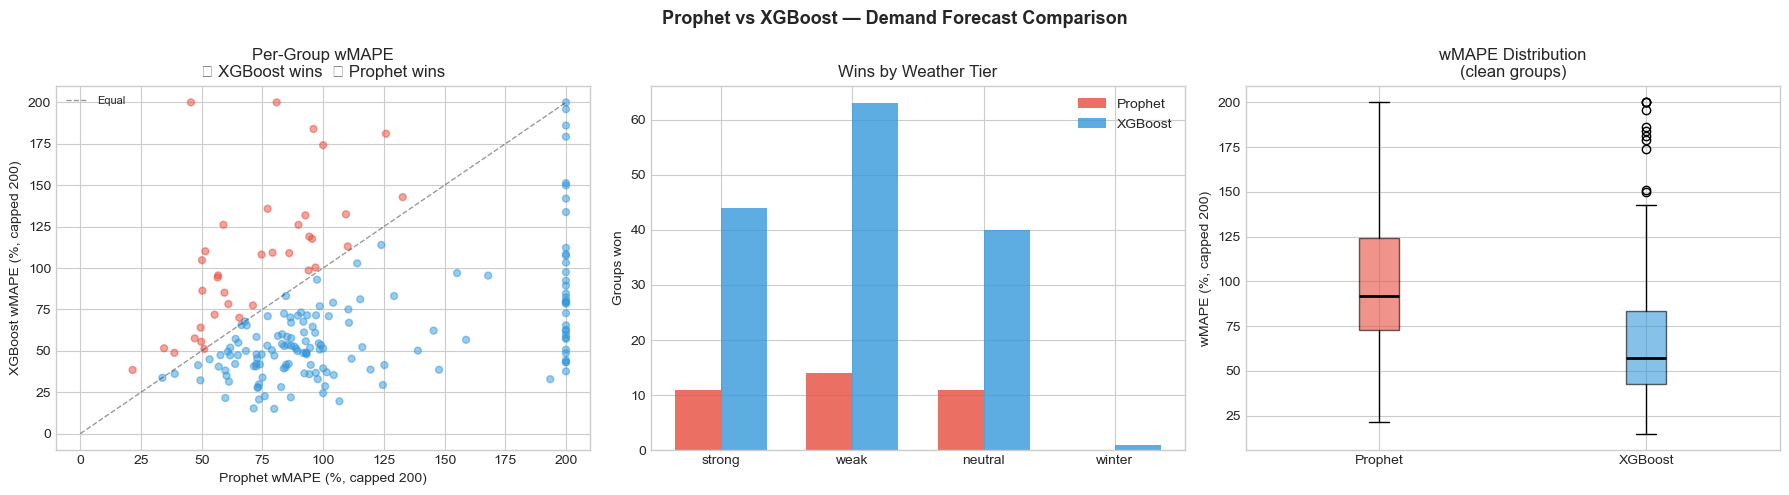

✅ Saved: prophet_vs_xgboost.png
✅ Saved: model_comparison_prophet_xgb.csv
✅ Saved: model_accuracy_xgboost.csv
✅ Saved: forecast_output_xgboost.csv

── ENSEMBLE SELECTION ────────────────────────────────────────────
  XGBoost selected : 152 groups  (train mean ≥ 5.0 units/wk)
  Prophet selected : 32 groups  (train mean < 5.0 units/wk)
  Prophet only     : 72 groups  (intermittent / lumpy / no XGB result)

  Ensemble wMAPE median (comparison groups): 60.8%
  vs Prophet alone                         : 92.0%
  vs XGBoost alone                         : 57.4%

  ✅ Saved: forecast_output_ensemble.csv (1472 rows)
     → Use this as the primary forecast for Power BI


In [53]:
if len(xgb_df) == 0:
    print("No XGBoost results — re-run Cell 5d.")
else:
    # ── Merge Prophet and XGBoost results on common groups ────────────────────
    prophet_clean = accuracy_df[
        ~(accuracy_df['is_collapse'] | accuracy_df['is_surge'] | accuracy_df['is_unreliable_div'])
        & accuracy_df['model_type'].isin(['weekly_prophet'])
    ][GROUP_COLS + ['wMAPE','RMSSE','MAE','Train_Mean','weather_tier']].copy()
    prophet_clean.columns = GROUP_COLS + ['wMAPE_P','RMSSE_P','MAE_P','Train_Mean','weather_tier']

    xgb_clean = xgb_df[
        ~(xgb_df['is_collapse'] | xgb_df['is_surge'] | xgb_df['is_unreliable_div'])
    ][GROUP_COLS + ['wMAPE','RMSSE','MAE']].copy()
    xgb_clean.columns = GROUP_COLS + ['wMAPE_X','RMSSE_X','MAE_X']

    compare = prophet_clean.merge(xgb_clean, on=GROUP_COLS, how='inner')
    n = len(compare)

    if n == 0:
        print("No overlapping groups between Prophet and XGBoost.")
    else:
        compare['winner'] = np.where(
            compare['wMAPE_X'] < compare['wMAPE_P'], 'XGBoost', 'Prophet'
        )
        compare['wMAPE_delta'] = compare['wMAPE_P'] - compare['wMAPE_X']  # + = XGB wins

        xgb_wins     = (compare['winner'] == 'XGBoost').sum()
        prophet_wins = (compare['winner'] == 'Prophet').sum()

        print('=' * 70)
        print('PROPHET vs XGBOOST — HEAD-TO-HEAD COMPARISON')
        print('=' * 70)
        print(f'Groups compared  : {n}')
        print(f'XGBoost wins     : {xgb_wins}  ({xgb_wins/n:.0%})')
        print(f'Prophet wins     : {prophet_wins}  ({prophet_wins/n:.0%})')
        print()
        print(f'Metric        Prophet   XGBoost')
        print(f'──────────    ───────   ───────')
        print(f'wMAPE median  {compare["wMAPE_P"].median():.1%}     {compare["wMAPE_X"].median():.1%}')
        print(f'RMSSE median  {compare["RMSSE_P"].median():.3f}     {compare["RMSSE_X"].median():.3f}')
        print(f'MAE median    {compare["MAE_P"].median():,.1f}      {compare["MAE_X"].median():,.1f} units/wk')
        print()

        # By weather tier
        print('Winner breakdown by weather tier:')
        tier_wins = compare.groupby('weather_tier')['winner'].value_counts().unstack(fill_value=0)
        print(tier_wins.to_string())
        print()

        # Top cases where XGBoost wins big
        print('Top 10 groups where XGBoost most outperforms Prophet (wMAPE delta):')
        top_xgb = compare.nlargest(10, 'wMAPE_delta')[[
            'store_code','division_code','weather_tier',
            'wMAPE_P','wMAPE_X','wMAPE_delta','Train_Mean']]
        print(top_xgb.to_string(index=False))
        print()

        # Top cases where Prophet wins big
        print('Top 10 groups where Prophet most outperforms XGBoost (wMAPE delta):')
        top_p = compare.nsmallest(10, 'wMAPE_delta')[[
            'store_code','division_code','weather_tier',
            'wMAPE_P','wMAPE_X','wMAPE_delta','Train_Mean']]
        print(top_p.to_string(index=False))

        # ── Visual comparison ─────────────────────────────────────────────────
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))

        # Scatter: wMAPE Prophet vs XGBoost per group
        axes[0].scatter(compare['wMAPE_P'].clip(upper=2)*100,
                        compare['wMAPE_X'].clip(upper=2)*100,
                        c=compare['winner'].map({'XGBoost':'#3498db','Prophet':'#e74c3c'}),
                        alpha=0.5, s=25)
        lim = 200
        axes[0].plot([0,lim],[0,lim], 'k--', linewidth=1, alpha=0.4, label='Equal')
        axes[0].set_xlabel('Prophet wMAPE (%, capped 200)')
        axes[0].set_ylabel('XGBoost wMAPE (%, capped 200)')
        axes[0].set_title('Per-Group wMAPE\n🔵 XGBoost wins  🔴 Prophet wins')
        axes[0].legend(fontsize=8)

        # Bar: wins by tier
        tier_order = ['strong','weak','neutral','winter']
        tier_p = compare[compare['winner']=='Prophet'].groupby('weather_tier').size().reindex(tier_order, fill_value=0)
        tier_x = compare[compare['winner']=='XGBoost'].groupby('weather_tier').size().reindex(tier_order, fill_value=0)
        x = np.arange(len(tier_order))
        w = 0.35
        axes[1].bar(x-w/2, tier_p, w, label='Prophet', color='#e74c3c', alpha=0.8)
        axes[1].bar(x+w/2, tier_x, w, label='XGBoost', color='#3498db', alpha=0.8)
        axes[1].set_xticks(x); axes[1].set_xticklabels(tier_order)
        axes[1].set_ylabel('Groups won'); axes[1].set_title('Wins by Weather Tier')
        axes[1].legend()

        # Box: wMAPE distribution comparison
        box_data = [compare['wMAPE_P'].dropna().clip(upper=2)*100,
                    compare['wMAPE_X'].dropna().clip(upper=2)*100]
        bp = axes[2].boxplot(box_data, labels=['Prophet','XGBoost'], patch_artist=True,
                             medianprops=dict(color='black', linewidth=2))
        bp['boxes'][0].set_facecolor('#e74c3c'); bp['boxes'][0].set_alpha(0.6)
        bp['boxes'][1].set_facecolor('#3498db'); bp['boxes'][1].set_alpha(0.6)
        axes[2].set_ylabel('wMAPE (%, capped 200)')
        axes[2].set_title('wMAPE Distribution\n(clean groups)')

        plt.suptitle('Prophet vs XGBoost — Demand Forecast Comparison', fontsize=13, fontweight='bold')
        plt.tight_layout()
        plt.savefig(FIGURES / 'prophet_vs_xgboost.png', dpi=150, bbox_inches='tight')
        plt.show()
        print('✅ Saved: prophet_vs_xgboost.png')

        # Save comparison table
        compare.to_csv(DATA_PROCESSED / 'model_comparison_prophet_xgb.csv', index=False)
        xgb_df.to_csv(DATA_PROCESSED / 'model_accuracy_xgboost.csv', index=False)
        xgb_forecast_df.to_csv(DATA_PROCESSED / 'forecast_output_xgboost.csv', index=False)
        print('✅ Saved: model_comparison_prophet_xgb.csv')
        print('✅ Saved: model_accuracy_xgboost.csv')
        print('✅ Saved: forecast_output_xgboost.csv')


        # ── Ensemble: pick best model per series ──────────────────────────────
        # Rule: use XGBoost unless Train_Mean < LOW_VOLUME_THRESHOLD,
        # in which case Prophet's seasonality curve is more reliable than lags.
        LOW_VOLUME_THRESHOLD = 5.0   # units/wk — tune if needed

        ensemble = compare.copy()
        ensemble['selected_model'] = np.where(
            ensemble['Train_Mean'] < LOW_VOLUME_THRESHOLD, 'Prophet', 'XGBoost'
        )

        # For groups that only have Prophet (intermittent/lumpy), keep Prophet
        prophet_only = accuracy_df[
            ~accuracy_df[GROUP_COLS].apply(tuple, axis=1).isin(
                compare[GROUP_COLS].apply(tuple, axis=1)
            )
        ][GROUP_COLS + ['model_type']].copy()
        prophet_only['selected_model'] = 'Prophet'

        n_xgb_selected     = (ensemble['selected_model'] == 'XGBoost').sum()
        n_prophet_selected = (ensemble['selected_model'] == 'Prophet').sum()
        n_prophet_only     = len(prophet_only)

        print()
        print('── ENSEMBLE SELECTION ────────────────────────────────────────────')
        print(f'  XGBoost selected : {n_xgb_selected} groups  (train mean ≥ {LOW_VOLUME_THRESHOLD} units/wk)')
        print(f'  Prophet selected : {n_prophet_selected} groups  (train mean < {LOW_VOLUME_THRESHOLD} units/wk)')
        print(f'  Prophet only     : {n_prophet_only} groups  (intermittent / lumpy / no XGB result)')
        print()

        # Simulate ensemble wMAPE on the comparison set
        ens_wmape = np.where(
            ensemble['selected_model'] == 'XGBoost',
            ensemble['wMAPE_X'],
            ensemble['wMAPE_P']
        )
        print(f'  Ensemble wMAPE median (comparison groups): {np.nanmedian(ens_wmape):.1%}')
        print(f'  vs Prophet alone                         : {compare["wMAPE_P"].median():.1%}')
        print(f'  vs XGBoost alone                         : {compare["wMAPE_X"].median():.1%}')

        # Build the ensemble forecast output by merging the two forecast DFs
        # and selecting the right rows per group
        xgb_sel_keys = set(
            ensemble[ensemble['selected_model'] == 'XGBoost']
                    .apply(lambda r: (r['store_code'], r['city'], r['division_code']), axis=1)
        )
        p_sel_keys = set(
            ensemble[ensemble['selected_model'] == 'Prophet']
                    .apply(lambda r: (r['store_code'], r['city'], r['division_code']), axis=1)
        )

        fc_prophet = forecast_df if 'forecast_df' in dir() else pd.DataFrame()
        fc_xgb     = xgb_forecast_df.copy() if len(xgb_forecast_df) else pd.DataFrame()

        rows = []
        if len(fc_xgb):
            xgb_rows = fc_xgb[
                fc_xgb.apply(lambda r: (r['store_code'], r['city'], r['division_code'])
                             in xgb_sel_keys, axis=1)
            ].copy()
            xgb_rows['model_selected'] = 'XGBoost'
            rows.append(xgb_rows)

        if len(fc_prophet):
            p_rows = fc_prophet[
                fc_prophet.apply(lambda r: (r['store_code'], r['city'], r['division_code'])
                                in p_sel_keys, axis=1)
            ].copy()
            p_rows['model_selected'] = 'Prophet'
            rows.append(p_rows)

        if rows:
            ensemble_forecast = pd.concat(rows, ignore_index=True)
            ensemble_forecast.to_csv(DATA_PROCESSED / 'forecast_output_ensemble.csv', index=False)
            print(f'\n  ✅ Saved: forecast_output_ensemble.csv ({len(ensemble_forecast)} rows)')
            print('     → Use this as the primary forecast for Power BI')


---
## Cell 6: Forecast Output Table

Primary deliverable for Power BI integration.

Schema: `store_code | city | division_code | Week | Forecast_Units | Lower_CI_Units | Upper_CI_Units`

---

In [54]:
forecast_df = pd.DataFrame(forecast_list)
forecast_df['Week'] = pd.to_datetime(forecast_df['Week'])
forecast_df = forecast_df.sort_values(GROUP_COLS + ['Week']).reset_index(drop=True)

print(f'Forecast output : {len(forecast_df):,} rows')
print(f'Horizon         : {FORECAST_HORIZON} weeks ahead')
print(f'Window          : {forecast_df["Week"].min().date()} → {forecast_df["Week"].max().date()}')
print()
print(forecast_df.head(20).to_string(index=False))


Forecast output : 2,048 rows
Horizon         : 8 weeks ahead
Window          : 2025-08-24 → 2026-05-10

   store_code   city division_code       Week  Forecast_Units  Lower_CI_Units  Upper_CI_Units
CP01 - Québec Québec            BQ 2026-03-15             0.0             0.0             3.0
CP01 - Québec Québec            BQ 2026-03-22             0.0             0.0             1.3
CP01 - Québec Québec            BQ 2026-03-29             0.0             0.0             2.4
CP01 - Québec Québec            BQ 2026-04-05             0.0             0.0             5.9
CP01 - Québec Québec            BQ 2026-04-12             2.4             0.0             8.5
CP01 - Québec Québec            BQ 2026-04-19             5.4             0.0            11.7
CP01 - Québec Québec            BQ 2026-04-26             0.1             0.0             6.3
CP01 - Québec Québec            BQ 2026-05-03             0.0             0.0             0.0
CP01 - Québec Québec            CH 2026-03-08     

In [55]:
# Store-level aggregate (useful for Power BI executive summary)
forecast_store = (
    forecast_df.groupby(['store_code', 'city', 'Week'])
               .agg(
                   Forecast_Units = ('Forecast_Units', 'sum'),
                   Lower_CI_Units = ('Lower_CI_Units', 'sum'),
                   Upper_CI_Units = ('Upper_CI_Units', 'sum'),
               )
               .reset_index()
)
print('Store-level aggregate (first 20 rows):')
print(forecast_store.head(20).to_string(index=False))


Store-level aggregate (first 20 rows):
   store_code   city       Week  Forecast_Units  Lower_CI_Units  Upper_CI_Units
CP01 - Québec Québec 2025-12-07             7.9             4.4            11.8
CP01 - Québec Québec 2025-12-14             8.1             4.1            11.7
CP01 - Québec Québec 2025-12-21             6.4             2.6            10.3
CP01 - Québec Québec 2025-12-28             1.6             0.0             5.3
CP01 - Québec Québec 2026-01-04             1.9             0.0             5.7
CP01 - Québec Québec 2026-01-11             0.0             0.0             2.8
CP01 - Québec Québec 2026-01-18             3.1             0.0             6.9
CP01 - Québec Québec 2026-01-25             0.1             0.0             3.6
CP01 - Québec Québec 2026-02-01            11.6             5.9            17.6
CP01 - Québec Québec 2026-02-08            22.1            16.3            28.0
CP01 - Québec Québec 2026-02-15            22.9            16.8            29.4
C

---
## Cell 7: Save Outputs
---

In [57]:
accuracy_df.to_csv(DATA_PROCESSED / 'model_accuracy.csv', index=False)
forecast_df.to_csv(DATA_PROCESSED / 'forecast_output.csv', index=False)
forecast_store.to_csv(DATA_PROCESSED / 'forecast_output_by_store.csv', index=False)

if sparse_list:
    pd.DataFrame(sparse_list).to_csv(DATA_PROCESSED / 'sparse_series_skipped.csv', index=False)

print(f'✅ model_accuracy.csv              ({len(accuracy_df)} groups)')
print(f'✅ forecast_output.csv             ({len(forecast_df):,} rows)')
print(f'✅ forecast_output_by_store.csv    ({len(forecast_store):,} rows)')
if sparse_list:
    print(f'✅ sparse_series_skipped.csv       ({len(sparse_list)} groups)')
print(f'''
Summary:
  Model              : Prophet (yearly + monthly seasonality, multiplicative)
  Changepoint scale  : {CHANGEPOINT_PRIOR_SCALE}
  Regressors         : {PROPHET_REGRESSORS}
  Lag features       : excluded from Prophet (kept in dataset for XGBoost, nb05)
  Horizon            : {FORECAST_HORIZON} weeks
  Groups modelled    : {len(results_list)}
  Groups skipped     : {len(skipped)}  (insufficient history)
  Groups sparse      : {len(sparse_list)}  (train mean < {SPARSE_TRAIN_THRESHOLD} units/wk)
  Overall wMAPE      : {accuracy_df["wMAPE"].dropna().mean():.1%}
  Overall MAE        : {accuracy_df["MAE"].dropna().mean():,.1f} units/wk
''')


✅ model_accuracy.csv              (256 groups)
✅ forecast_output.csv             (2,048 rows)
✅ forecast_output_by_store.csv    (654 rows)
✅ sparse_series_skipped.csv       (20 groups)

Summary:
  Model              : Prophet (yearly + monthly seasonality, multiplicative)
  Changepoint scale  : 0.1
  Regressors         : ['avg_temp', 'temp_above_25', 'bad_weather_days', 'snow_days', 'has_holiday']
  Lag features       : excluded from Prophet (kept in dataset for XGBoost, nb05)
  Horizon            : 8 weeks
  Groups modelled    : 256
  Groups skipped     : 280  (insufficient history)
  Groups sparse      : 20  (train mean < 3.0 units/wk)
  Overall wMAPE      : 1087.0%
  Overall MAE        : 81.3 units/wk

